# Enhancing the Motif Pipeline with HRV Features

Our main pipeline (`stress_detection.ipynb`) detects stress by measuring how much a sliding ECG window deviates from a subject's learned baseline motifs, which is a purely morphological approach.

This notebook investigates whether adding **Heart Rate Variability (HRV)** features alongside the motif distance can improve detection performance. HRV captures physiological changes that the waveform shape alone may not fully express, such as the rigidity of the heartbeat interval during sympathetic nervous system activation.

The experiment uses the exact same train / validation / test split, the same motif learning procedure, and the same threshold-search methodology as the main pipeline to ensure a fair comparison.



## 1. Instructions

To reproduce these results, please ensure the following dependencies are installed:
* Python 3.8+
* `numpy`, `pandas`, `matplotlib`, `scipy`, `scikit-learn`
* `stumpy` 

**Data Path:** This notebook looks for WESAD `.pkl` files in the `../data/` directory, identical to `stress_detection.ipynb`.

**Execution:** Click `Kernel -> Restart & Run All` to reproduce the full pipeline top-to-bottom.

>  The motif-only baseline results in the final comparison table are re-computed here from scratch (not imported) to guarantee reproducibility on any machine.

## 2. Environment Setup

In [1]:
# If you are missing any libraries, or running this in Google Colab,
# remove the '#' from the line below and run this cell to install them.

#!pip install stumpy scikit-learn matplotlib pandas numpy scipy --quiet

## 3. Imports

In [1]:
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import stumpy

from scipy import signal as scipy_signal
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

print("All imports successful.")

All imports successful.


## 4. Setting the Hyperparameters

All constants below are identical to those used in `stress_detection.ipynb` to ensure a fair comparison.

* **Sampling Frequency (FS):** 700 Hz : matches the WESAD chest ECG sensor.
* **Window Size (M_FIXED):** 1050 samples (1.5 s) : captures one complete cardiac cycle.
* **Motif Count (K_FIXED):** 5 : top recurring baseline patterns.
* **Train / Val split:** 300 s train, 180 s validation, remainder for testing.
* **HRV Window (HRV_WIN_SEC):** 30-second sliding window with a 10-second step : standard in HRV literature for short-term analysis.

In [2]:
DATA_PATH = os.path.normpath(os.path.join(os.getcwd(), "..", "data"))

SUBJECTS    = [f"S{i}" for i in range(2, 18) if i != 12]

FS          = 700
M_FIXED     = 1050
K_FIXED     = 5
TRAIN_SEC   = 300
VAL_SEC     = 180

HRV_WIN_SEC  = 15  
HRV_STEP_SEC =  5   

print(f"Data path  : {DATA_PATH}")
print(f"Subjects   : {SUBJECTS}")
print(f"m={M_FIXED} ({M_FIXED/FS:.2f}s), K={K_FIXED}, FS={FS} Hz")
print(f"Train: {TRAIN_SEC}s | Val: {VAL_SEC}s | Test: remainder")
print(f"HRV window : {HRV_WIN_SEC}s, step: {HRV_STEP_SEC}s")

Data path  : C:\Users\HP\Desktop\Capstone_Project\data
Subjects   : ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']
m=1050 (1.50s), K=5, FS=700 Hz
Train: 300s | Val: 180s | Test: remainder
HRV window : 15s, step: 5s


## 5. Shared Pipeline Functions

These four functions are extracted from `stress_detection.ipynb` so this notebook is fully self-contained and reproducible.

In [3]:
def load_subject(subject_id, data_path=DATA_PATH):
    """
    Load one WESAD subject's chest ECG and return preprocessed
    (baseline_ecg, stress_ecg) as 1-D arrays at 700 Hz.

    WESAD labels used:
        1 = Baseline (resting)
        2 = Stress   (TSST experiment)
    """
    path_a = os.path.join(data_path, f"{subject_id}.pkl")
    path_b = os.path.join(data_path, subject_id, f"{subject_id}.pkl")

    if   os.path.exists(path_a): path = path_a
    elif os.path.exists(path_b): path = path_b
    else:
        raise FileNotFoundError(
            f"Cannot find {subject_id}.pkl\n"
            f"  Tried: {path_a}\n"
            f"  Tried: {path_b}\n"
            f"  Update DATA_PATH in Section 2."
        )

    with open(path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    ecg_raw = data["signal"]["chest"]["ECG"].flatten()
    labels  = data["label"].flatten()

    baseline_ecg = _preprocess_ecg(ecg_raw[labels == 1])
    stress_ecg   = _preprocess_ecg(ecg_raw[labels == 2])
    return baseline_ecg, stress_ecg


def _preprocess_ecg(sig, fs=FS):
    """
    Step 1: Bandpass filter (0.5-45 Hz, 3rd-order Butterworth).
            Removes baseline wander and high-frequency noise while
            preserving QRS waveform morphology.

    Step 2: Z-score normalisation — eliminates inter-subject amplitude
            differences so motif distances are comparable.
    """
    nyq  = 0.5 * fs
    b, a = scipy_signal.butter(3, [0.5 / nyq, 45.0 / nyq], btype="band")
    filt = scipy_signal.filtfilt(b, a, sig)
    return (filt - filt.mean()) / filt.std()


def split_subject_data(baseline_ecg, stress_ecg,
                       train_sec=TRAIN_SEC, val_sec=VAL_SEC, fs=FS):
    """
    Strict non-overlapping split — no sample appears in more than one set.

    Returns:
        train_baseline  ->  first train_sec of baseline  -> for motif learning
        val_baseline    ->  next  val_sec  of baseline   -> for threshold tuning
        val_stress      ->  first val_sec  of stress     -> for threshold tuning
        test_baseline   ->  remainder of baseline        -> for final evaluation
        test_stress     ->  remainder of stress          -> for final evaluation
    """
    train_n = train_sec * fs
    val_n   = val_sec   * fs
    return (
        baseline_ecg[:train_n],
        baseline_ecg[train_n : train_n + val_n],
        stress_ecg[:val_n],
        baseline_ecg[train_n + val_n:],
        stress_ecg[val_n:],
    )


def get_motifs(calib_signal, m=M_FIXED, k=K_FIXED):
    """
    Computes the Matrix Profile and extracts k non-overlapping motifs
    (the most repetitive heartbeat subsequences).
    """
    mp          = stumpy.stump(calib_signal, m)
    sorted_idxs = np.argsort(mp[:, 0])

    chosen = []
    for idx in sorted_idxs:
        if len(chosen) >= k:
            break
        if all(abs(idx - s) > m for s in chosen):
            chosen.append(idx)

    return [calib_signal[i : i + m] for i in chosen]


def compute_distance_profile(ecg_segment, motifs, smoothing_window=FS * 3):
    """
    For every sliding window in ecg_segment, compute the minimum
    z-normalised Euclidean distance to any of the learned motifs.
    A 3-second moving-average is applied to reduce transient noise.
    """
    all_dists = [stumpy.mass(motif, ecg_segment) for motif in motifs]
    min_dist  = np.min(all_dists, axis=0)
    padded    = np.pad(min_dist, (0, len(ecg_segment) - len(min_dist)),
                       constant_values=np.nan)
    smoothed  = (pd.Series(padded)
                 .rolling(window=smoothing_window, min_periods=1)
                 .mean().values)
    return smoothed


def find_best_threshold(val_bl_dist, val_st_dist, pct_range=range(50, 100)):
    """
    Grid search over percentiles 50-99 on the validation set.
    Threshold is derived from baseline only — no stress labels used.
    Returns (results_df, best_pct, best_thr, best_f1).
    """
    y_true   = np.concatenate([np.zeros(len(val_bl_dist)),
                                np.ones(len(val_st_dist))])
    all_dist = np.concatenate([val_bl_dist, val_st_dist])
    valid    = ~np.isnan(all_dist)

    best_f1, best_pct, best_thr = 0, 90, np.nanpercentile(val_bl_dist, 90)
    rows = []

    for pct in pct_range:
        thr    = np.nanpercentile(val_bl_dist, pct)
        y_pred = (all_dist > thr).astype(int)
        f1     = f1_score(y_true[valid], y_pred[valid], zero_division=0)
        rows.append({"percentile": pct, "threshold": thr, "f1": f1})
        if f1 > best_f1:
            best_f1, best_pct, best_thr = f1, pct, thr

    return pd.DataFrame(rows), best_pct, best_thr, best_f1


print("All shared functions defined.")

All shared functions defined.


## 6. HRV Feature Extraction

Heart Rate Variability (HRV) quantifies the fluctuation in time intervals between consecutive heartbeats (RR intervals). These fluctuations reflect the balance between the sympathetic and parasympathetic branches of the autonomic nervous system.

Under psychological stress, the sympathetic branch dominates, thus the heart speeds up and its rhythm becomes more rigid and less variable. We capture this with four standard HRV metrics:

| Feature | What it measures | Expected change under stress |
|---|---|---|
| **mean_rr** | Average time between beats | ↓ decreases (faster heart rate) |
| **sdnn** | Standard deviation of RR intervals | ↓ decreases (heart becomes rigid) |
| **rmssd** | Root mean square of successive RR differences  | ↓ decreases (relaxation system suppressed) |
| **hr** | Mean heart rate (bpm) | ↑ increases |

In [4]:
def extract_hrv_features(ecg_segment, fs=FS,
                          window_sec=HRV_WIN_SEC,
                          step_sec=HRV_STEP_SEC):
    
    """
    Slide a window over ecg_segment, detect R-peaks in each window,
    and compute four time-domain HRV features.

    R-peak detection parameters:
        height   = 0.5  : works for z-scored ECG signals
        distance = 0.4s : enforces a physiological minimum of 40ms between
                          consecutive peaks 

    Windows with fewer than 4 detected beats are skipped because RR intervals
    are too few to compute meaningful HRV statistics.

    Args:
        ecg_segment : 1-D preprocessed ECG array
        fs          : sampling frequency in Hz
        window_sec  : length of each analysis window in seconds
        step_sec    : step size between consecutive windows in seconds

    Returns:
        DataFrame with columns [window_center_s, mean_rr, sdnn, rmssd, hr],
        one row per valid window.
    """
    
    window_samples = int(window_sec * fs)
    step_samples   = int(step_sec   * fs)
    rows = []

    for start in range(0, len(ecg_segment) - window_samples, step_samples):
        end     = start + window_samples
        segment = ecg_segment[start:end]

        peaks, _ = find_peaks(segment, height=0.5, distance=int(0.4 * fs))

        if len(peaks) < 4:
            continue

        rr       = np.diff(peaks) / fs * 1000   
        mean_rr  = np.mean(rr)
        sdnn     = np.std(rr)
        rmssd    = np.sqrt(np.mean(np.diff(rr) ** 2))
        hr       = 60000 / mean_rr

        rows.append({
            "window_center_s" : (start + window_samples / 2) / fs,
            "mean_rr"         : mean_rr,
            "sdnn"            : sdnn,
            "rmssd"           : rmssd,
            "hr"              : hr,   
        })

    return pd.DataFrame(rows)


print("extract_hrv_features() defined.")

extract_hrv_features() defined.


## 7. Combined Scoring

To combine motif distance and HRV into a single anomaly score, both must be computed on the same temporal windows. The function below slides a 30-second window (step: 10 s) over the ECG and, for each window, extracts:

1. **Motif distance** — mean anomaly score within that window .
2. **HRV features** — `mean_rr`, `sdnn`, `rmssd`, `hr` .

This produces one unified feature vector per window rather than two separate time-series.

In [5]:
def compute_combined_features(ecg_segment, motifs, m=M_FIXED, fs=FS,
                               window_sec=HRV_WIN_SEC,
                               step_sec=HRV_STEP_SEC):
    
    """
    For each sliding window, computes motif distance + HRV features
    and returns them as a single unified DataFrame.

    Motif distance is the mean minimum z-normalised Euclidean distance
    from every sub-window inside the 30-second window to any learned motif.

    Args:
        ecg_segment : 1-D preprocessed ECG array
        motifs      : list of motif arrays from get_motifs()
        m           : motif window length 
        fs          : sampling frequency
        window_sec  : HRV analysis window length in seconds
        step_sec    : step size in seconds

    Returns:
        DataFrame with columns:
            [window_center_s, motif_dist, mean_rr, sdnn, rmssd, hr]
    """
    
    window_samples = int(window_sec * fs)
    step_samples   = int(step_sec   * fs)
    rows = []

    for start in range(0, len(ecg_segment) - window_samples, step_samples):
        end     = start + window_samples
        segment = ecg_segment[start:end]

        
        all_dists  = [stumpy.mass(motif, segment) for motif in motifs]
        min_dist   = np.min(all_dists, axis=0)
        mean_dist  = np.nanmean(min_dist)

        
        peaks, _ = find_peaks(segment, height=0.5, distance=int(0.4 * fs))

        if len(peaks) < 4:
            continue

        rr      = np.diff(peaks) / fs * 1000
        mean_rr = np.mean(rr)
        sdnn    = np.std(rr)
        rmssd   = np.sqrt(np.mean(np.diff(rr) ** 2))
        hr      = 60000 / mean_rr

        rows.append({
            "window_center_s" : (start + window_samples / 2) / fs,
            "motif_dist"      : mean_dist,
            "mean_rr"         : mean_rr,
            "sdnn"            : sdnn,
            "rmssd"           : rmssd,
            
        })

    return pd.DataFrame(rows)


print("compute_combined_features() defined.")

compute_combined_features() defined.


### 7.2 Building the Combined Anomaly Score

After computing features, we need a single score per window so we can apply a threshold and classify each window as Stressed or Not Stressed.

The approach:
1. **Normalise** each feature using `StandardScaler` fitted on the **validation baseline only** 

2. **Flip signs** so that all features point in the same direction, so higher score always means "more stressed". Specifically: `motif_dist` and `hr` increase under stress, while `mean_rr`, `sdnn`, and `rmssd` decrease.

3. **Average** the signed, normalised features into one combined stress index.



In [6]:
# mean_rr, sdnn, rmssd are all derived from the same RR sequence and
# move together under stress. Averaging them votes 3x with the same
# evidence → recall artificially collapses to 1.0.
# rmssd is kept because it captures parasympathetic variability most
# independently of the raw heart rate level that motif_dist already
# partially encodes through window shape changes.

FEATURE_COLS = ["motif_dist", "rmssd"]

EXPECTED_DIRECTIONS = {
    "motif_dist" : +1,
    "rmssd"      : -1,
}




def build_combined_score(tr_bl_feat, val_bl_feat, val_st_feat, te_bl_feat, te_st_feat):

    """
    Fits a scaler on training baseline,
    then calculates a balanced anomaly score by weighting Morphology and HRV equally.
    
    """

    scaler = StandardScaler()
    scaler.fit(tr_bl_feat[FEATURE_COLS])  
    
    dir_vec = np.array([EXPECTED_DIRECTIONS[f] for f in FEATURE_COLS])

    def _calculate_balanced_score(feat_df):
        scaled   = scaler.transform(feat_df[FEATURE_COLS])
        directed = scaled * dir_vec         

        motif_part = directed[:, 0]          
        hrv_part   = directed[:, 1]          
                                             
        return (motif_part + hrv_part) / 2

    return (
        _calculate_balanced_score(val_bl_feat),
        _calculate_balanced_score(val_st_feat),
        _calculate_balanced_score(te_bl_feat),
        _calculate_balanced_score(te_st_feat),
        scaler,
        EXPECTED_DIRECTIONS
    )

def find_best_threshold_1d(val_bl_scores, val_st_scores,
                            pct_range=range(50, 100)):
    
    """
    
    Same grid-search logic as find_best_threshold() in the main pipeline,
    but operates on 1-D score arrays instead of distance profiles.
    Threshold derived from baseline scores only.
    Returns (best_pct, best_thr, best_f1).
    
    """
    
    y_true   = np.concatenate([np.zeros(len(val_bl_scores)),
                                np.ones(len(val_st_scores))])
    all_sc   = np.concatenate([val_bl_scores, val_st_scores])

    best_f1, best_pct, best_thr = 0, 90, np.percentile(val_bl_scores, 90)

    for pct in pct_range:
        thr    = np.percentile(val_bl_scores, pct)
        y_pred = (all_sc > thr).astype(int)
        f1     = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_pct, best_thr = f1, pct, thr

    return best_pct, best_thr, best_f1


print("build_combined_score() and find_best_threshold_1d() defined.")

build_combined_score() and find_best_threshold_1d() defined.


## 8. Single-Subject Demonstration on Subject S2

Here, we demonstrate the complete Motif+HRV approach on S2, who is the same subject used in `stress_detection.ipynb` , so the two can be directly compared.

### 8.1 Load, Split,  Learn Motifs

In [7]:
bl_s2, st_s2 = load_subject("S2")

tr_bl, val_bl, val_st, te_bl, te_st = split_subject_data(bl_s2, st_s2)

print(f"Baseline : {len(bl_s2):,} samples  ({len(bl_s2)/FS/60:.1f} min)")
print(f"Stress   : {len(st_s2):,} samples  ({len(st_s2)/FS/60:.1f} min)")
print(f"  Train  baseline : {len(tr_bl):>8,}  ({len(tr_bl)/FS/60:.1f} min)")
print(f"  Val    baseline : {len(val_bl):>8,}  ({len(val_bl)/FS/60:.1f} min)")
print(f"  Val    stress   : {len(val_st):>8,}  ({len(val_st)/FS/60:.1f} min)")
print(f"  Test   baseline : {len(te_bl):>8,}  ({len(te_bl)/FS/60:.1f} min)")
print(f"  Test   stress   : {len(te_st):>8,}  ({len(te_st)/FS/60:.1f} min)")

motifs_s2 = get_motifs(tr_bl)
print(f"\nExtracted {len(motifs_s2)} motifs, each {M_FIXED} samples ({M_FIXED/FS:.2f}s).")

Baseline : 800,800 samples  (19.1 min)
Stress   : 430,500 samples  (10.2 min)
  Train  baseline :  210,000  (5.0 min)
  Val    baseline :  126,000  (3.0 min)
  Val    stress   :  126,000  (3.0 min)
  Test   baseline :  464,800  (11.1 min)
  Test   stress   :  304,500  (7.2 min)

Extracted 5 motifs, each 1050 samples (1.50s).


### 8.2 Visualising HRV Differences Between Baseline and Stress

Before building the combined score, we verify that HRV features actually separate the two conditions for S2.

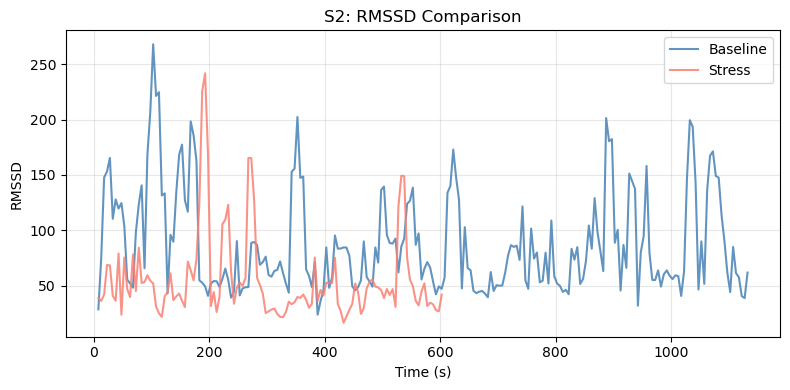

S2: Mean HRV Feature Values
Feature          Baseline       Stress      Direction
----------------------------------------------------
rmssd              87.599       55.239   ↓ stress  ✓


In [10]:
hrv_bl_s2 = extract_hrv_features(bl_s2)
hrv_st_s2 = extract_hrv_features(st_s2)

features       = ["rmssd"]
feature_labels = ["RMSSD"]


fig, ax = plt.subplots(figsize=(8, 4))

for feat, label in zip(features, feature_labels):
    ax.plot(hrv_bl_s2["window_center_s"], hrv_bl_s2[feat],
            color="steelblue", lw=1.5, label="Baseline", alpha=0.85)
    ax.plot(hrv_st_s2["window_center_s"], hrv_st_s2[feat],
            color="salmon",    lw=1.5, label="Stress",   alpha=0.85)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(label)
    ax.set_title(f"S2: {label} Comparison")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


print("S2: Mean HRV Feature Values")
print(f"{'Feature':<12} {'Baseline':>12} {'Stress':>12} {'Direction':>14}")
print("-" * 52)
for feat, label in zip(features, feature_labels):
    bl_mean = hrv_bl_s2[feat].mean()
    st_mean = hrv_st_s2[feat].mean()
    expected_dir = EXPECTED_DIRECTIONS[feat]
    actual_dir   = +1 if st_mean >= bl_mean else -1
    match = "✓" if actual_dir == expected_dir else "REVERSED"
    direction_str = "↑ stress" if actual_dir == +1 else "↓ stress"
    print(f"{feat:<12} {bl_mean:>12.3f} {st_mean:>12.3f} {direction_str:>10}  {match}")

The table confirms the expected physiological response for S2. The heart rate increases, while RR intervals and HRV indices (SDNN, RMSSD) all decrease , which indicates the presence of acute psychological stress.

### 8.3 Computing Combined Features and Tuning the Threshold

In [11]:
tr_bl_feat_s2  = compute_combined_features(tr_bl,  motifs_s2)  # ← added
val_bl_feat_s2 = compute_combined_features(val_bl, motifs_s2)
val_st_feat_s2 = compute_combined_features(val_st, motifs_s2)
te_bl_feat_s2  = compute_combined_features(te_bl,  motifs_s2)
te_st_feat_s2  = compute_combined_features(te_st,  motifs_s2)

print(f" Train baseline windows    : {len(tr_bl_feat_s2)}")
print(f" Validation baseline windows : {len(val_bl_feat_s2)}")
print(f" Validation stress windows   : {len(val_st_feat_s2)}")
print(f" Test baseline windows       : {len(te_bl_feat_s2)}")
print(f" Test stress windows         : {len(te_st_feat_s2)}")

vbl_sc, vst_sc, tbl_sc, tst_sc, scaler_s2, dirs_s2 = build_combined_score(
    tr_bl_feat_s2,                           # ← added
    val_bl_feat_s2, val_st_feat_s2,
    te_bl_feat_s2,  te_st_feat_s2
)


print("\nFeature directions used for S2:")
for feat, d in dirs_s2.items():
    print(f"  {feat:<14} : {'↑ stress (+1)' if d == 1 else '↓ stress (-1)'}")


best_pct_s2, best_thr_s2, val_f1_s2 = find_best_threshold_1d(vbl_sc, vst_sc)
print(f"\nBest threshold : {best_pct_s2}th percentile = {best_thr_s2:.4f}")
print(f"Validation F1  : {val_f1_s2:.4f}")

 Train baseline windows    : 57
 Validation baseline windows : 33
 Validation stress windows   : 33
 Test baseline windows       : 130
 Test stress windows         : 84

Feature directions used for S2:
  motif_dist     : ↑ stress (+1)
  rmssd          : ↓ stress (-1)

Best threshold : 97th percentile = 0.4478
Validation F1  : 0.9851


### 8.4 Evaluation on the Test Set

In [12]:

y_true = np.concatenate([np.zeros(len(tbl_sc)), np.ones(len(tst_sc))])
y_pred = np.concatenate([
    (tbl_sc > best_thr_s2).astype(int),
    (tst_sc > best_thr_s2).astype(int)
])

print("══════════════════════════════════════════")
print("  S2 : Motif+HRV : Final Test Results")
print("══════════════════════════════════════════")
print(f"  Threshold      : {best_pct_s2}th pct = {best_thr_s2:.4f}")
print(f"  Accuracy       : {accuracy_score(y_true, y_pred):.4f}")
print(f"  Precision      : {precision_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  Recall         : {recall_score(y_true, y_pred, zero_division=0):.4f}")
print(f"  F1 Score       : {f1_score(y_true, y_pred, zero_division=0):.4f}")

══════════════════════════════════════════
  S2 : Motif+HRV : Final Test Results
══════════════════════════════════════════
  Threshold      : 97th pct = 0.4478
  Accuracy       : 0.9065
  Precision      : 0.8721
  Recall         : 0.8929
  F1 Score       : 0.8824


### 8.5 Visualising the Combined Score

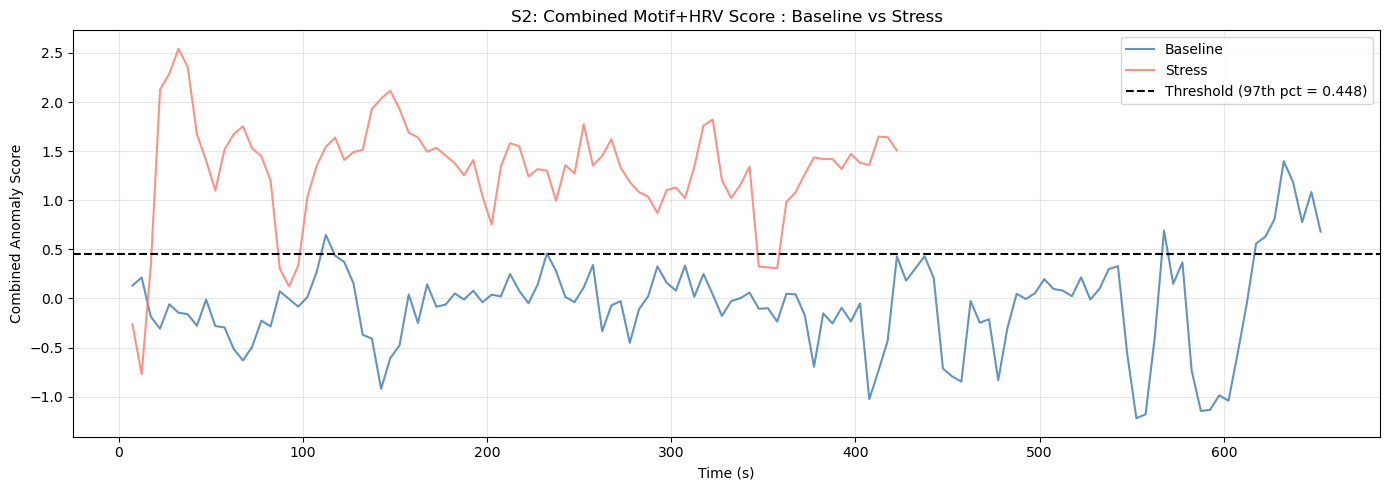

In [13]:

fig, ax = plt.subplots(figsize=(14, 5)) 

t_bl = te_bl_feat_s2["window_center_s"].values
t_st = te_st_feat_s2["window_center_s"].values


ax.plot(t_bl, tbl_sc, color="steelblue", lw=1.5, label="Baseline", alpha=0.85)
ax.plot(t_st, tst_sc, color="salmon",    lw=1.5, label="Stress",   alpha=0.85)
ax.axhline(best_thr_s2, color="black", linestyle="--",
                label=f"Threshold ({best_pct_s2}th pct = {best_thr_s2:.3f})")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Combined Anomaly Score")
ax.set_title("S2: Combined Motif+HRV Score : Baseline vs Stress")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout() 
plt.show()

## 9. Full Pipeline Across All 15 Subjects

We now run both approaches : **Motif-only** and **Motif+HRV** on all 15 subjects using the identical train/validation/test split.

The motif-only results are re-computed here from scratch (not imported from `stress_detection.ipynb`) to guarantee full reproducibility.

In [14]:
all_results = []

header = (f"{'Subject':<10} "
          f"{'Motif F1':>9} {'Motif Acc':>10} {'Motif Pre':>10} {'Motif Rec':>10}  "
          f"{'HRV F1':>8} {'HRV Acc':>9} {'HRV Pre':>9} {'HRV Rec':>9}")
print(header)
print("─" * len(header))

for sub in SUBJECTS:
    try:
        bl, st = load_subject(sub)

        if (len(bl) < (TRAIN_SEC + VAL_SEC + 60) * FS or
                len(st) < (VAL_SEC + 60) * FS):
            print(f"{sub:<10}  skipped — insufficient data")
            continue

        tr_bl, val_bl, val_st, te_bl, te_st = split_subject_data(bl, st)
        motifs = get_motifs(tr_bl)

        
        vbl_d = compute_distance_profile(val_bl, motifs)
        vst_d = compute_distance_profile(val_st, motifs)
        _, mo_pct, mo_thr, _ = find_best_threshold(vbl_d, vst_d)

        tbl_d = compute_distance_profile(te_bl, motifs)
        tst_d = compute_distance_profile(te_st, motifs)

        
        te_n  = min(len(tbl_d), len(tst_d))
        tbl_d = tbl_d[:te_n]
        tst_d = tst_d[:te_n]

        yt    = np.concatenate([np.zeros(te_n), np.ones(te_n)])
        yp_mo = np.concatenate([
            (tbl_d > mo_thr).astype(int),
            (tst_d > mo_thr).astype(int)
        ])
        v      = ~np.isnan(yp_mo)
        mo_f1  = f1_score(yt[v],        yp_mo[v].astype(int), zero_division=0)
        mo_acc = accuracy_score(yt[v],  yp_mo[v].astype(int))
        mo_pre = precision_score(yt[v], yp_mo[v].astype(int), zero_division=0)
        mo_rec = recall_score(yt[v],    yp_mo[v].astype(int), zero_division=0)

        
        trbf = compute_combined_features(tr_bl, motifs)
        vbl_f = compute_combined_features(val_bl, motifs)
        vst_f = compute_combined_features(val_st, motifs)
        tbl_f = compute_combined_features(te_bl, motifs)
        tst_f = compute_combined_features(te_st, motifs)

        if len(trbf) < 3 or len(vbl_f) < 3 or len(vst_f) < 3 or len(tbl_f) < 3 or len(tst_f) < 3:
            print(f"{sub:<10} skipped (Motif+HRV) — too few HRV windows")
            continue

        vbl_sc, vst_sc, tbl_sc, tst_sc, _, _ = build_combined_score(
            trbf,
            vbl_f, vst_f, tbl_f, tst_f
        )

        
        hrv_pct, hrv_thr, _ = find_best_threshold_1d(vbl_sc, vst_sc)

        
        hrv_n  = min(len(tbl_sc), len(tst_sc))
        tbl_sc_bal = tbl_sc[:hrv_n]
        tst_sc_bal = tst_sc[:hrv_n]

        yt_h   = np.concatenate([np.zeros(hrv_n), np.ones(hrv_n)])
        yp_h   = np.concatenate([
            (tbl_sc_bal > hrv_thr).astype(int),
            (tst_sc_bal > hrv_thr).astype(int)
        ])
        hrv_f1  = f1_score(yt_h,        yp_h, zero_division=0)
        hrv_acc = accuracy_score(yt_h,  yp_h)
        hrv_pre = precision_score(yt_h, yp_h, zero_division=0)
        hrv_rec = recall_score(yt_h,    yp_h, zero_division=0)

        all_results.append({
            "Subject"         : sub,
            "Motif_F1"        : round(mo_f1,   4),
            "Motif_Accuracy"  : round(mo_acc,  4),
            "Motif_Precision" : round(mo_pre,  4),
            "Motif_Recall"    : round(mo_rec,  4),
            "HRV_F1"          : round(hrv_f1,  4),
            "HRV_Accuracy"    : round(hrv_acc, 4),
            "HRV_Precision"   : round(hrv_pre, 4),
            "HRV_Recall"      : round(hrv_rec, 4),
            "F1_Delta"        : round(hrv_f1 - mo_f1, 4),
        })

        print(f"{sub:<10} "
              f"{mo_f1:>9.3f} {mo_acc:>10.3f} {mo_pre:>10.3f} {mo_rec:>10.3f} "
              f"{hrv_f1:>8.3f} {hrv_acc:>9.3f} {hrv_pre:>9.3f} {hrv_rec:>9.3f} "
              f"  [{hrv_n} win/class]")

    except FileNotFoundError as e:
        print(f"{sub:<10}  FILE NOT FOUND — {e}")
    except Exception as e:
        print(f"{sub:<10}  ERROR — {e}")

df_results = pd.DataFrame(all_results)

Subject     Motif F1  Motif Acc  Motif Pre  Motif Rec    HRV F1   HRV Acc   HRV Pre   HRV Rec
─────────────────────────────────────────────────────────────────────────────────────────────
S2             0.879      0.885      0.921      0.842    0.932     0.935     0.974     0.893   [84 win/class]
S3             0.861      0.870      0.921      0.809    0.989     0.989     1.000     0.978   [89 win/class]
S4             0.750      0.726      0.689      0.823    0.941     0.938     0.897     0.989   [88 win/class]
S5             0.789      0.747      0.676      0.947    0.915     0.917     0.931     0.900   [90 win/class]
S6             0.752      0.700      0.641      0.909    0.664     0.610     0.583     0.769   [91 win/class]
S7             0.472      0.483      0.483      0.462    0.236     0.309     0.264     0.213   [89 win/class]
S8             0.047      0.254      0.065      0.037    0.000     0.411     0.000     0.000   [95 win/class]
S9             0.408      0.503      0.505

In [15]:
df_display = df_results.copy()
mean_row = df_display.mean(numeric_only=True)
df_display.loc["Mean"] = mean_row
df_display.at["Mean", "Subject"] = "Overall Average"

df_display.style \
    .format({
        "MO_F1"        : "{:.3f}",
        "MO_Accuracy"  : "{:.3f}",
        "MO_Precision" : "{:.3f}",
        "MO_Recall"    : "{:.3f}",
        "HRV_F1"       : "{:.3f}",
        "HRV_Accuracy" : "{:.3f}",
        "HRV_Precision": "{:.3f}",
        "HRV_Recall"   : "{:.3f}",
        "F1_Delta"     : "{:+.3f}",
    }) \
    .applymap(lambda v: "color: green; font-weight: bold" if isinstance(v, float) and v > 0
              else ("color: red" if isinstance(v, float) and v < 0 else ""),
              subset=["F1_Delta"])

,Subject,Motif_F1,Motif_Accuracy,Motif_Precision,Motif_Recall,HRV_F1,HRV_Accuracy,HRV_Precision,HRV_Recall,F1_Delta
0,S2,0.879400,0.884600,0.920800,0.841600,0.932,0.934,0.974,0.893,+0.052
1,S3,0.861500,0.869900,0.921100,0.809100,0.989,0.989,1.000,0.978,+0.127
2,S4,0.749900,0.725600,0.688900,0.822800,0.941,0.938,0.897,0.989,+0.191
3,S5,0.789100,0.746900,0.676300,0.947100,0.915,0.917,0.931,0.900,+0.126
4,S6,0.752000,0.700100,0.641000,0.909500,0.663,0.610,0.583,0.769,-0.088
5,S7,0.472000,0.483400,0.482700,0.461900,0.236,0.309,0.264,0.213,-0.236
6,S8,0.047000,0.253600,0.065000,0.036800,0.000,0.410,0.000,0.000,-0.047
7,S9,0.408300,0.503400,0.505100,0.342600,0.189,0.428,0.324,0.133,-0.219
8,S10,0.859500,0.840500,0.767700,0.976300,0.724,0.741,0.774,0.679,-0.136
9,S11,0.607900,0.548400,0.537200,0.700200,0.930,0.928,0.903,0.959,+0.322
